# SkinXAI Expert Model — BKL / SCC / AK Ayırt Edici
## Cascade Mimarisi: 2. Aşama Uzman Model

Ana ensemble (v3+v6) BKL/SCC/AK tahmin ettiğinde devreye girer.

**Datasets:**
- `cdeotte/jpeg-isic2019-384x384` → BKL, SCC, AK (ISIC 2019)
- `skinxai-expert-data` → Ek SCC (1717) ve AK (2800) görüntüsü

**Hedef:** SCC ve AK recall'ını %60+ üzerine çıkarmak

In [1]:
!pip install timm albumentations -q

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import cv2, os, random
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
import warnings; warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Cihaz: {device}')
if torch.cuda.is_available():
    print(f'GPU  : {torch.cuda.get_device_name(0)}')
else:
    print('⚠️  GPU YOK!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 110.4 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which

In [2]:
# ── Sabitler & Yollar ────────────────────────────────────────
ISIC19_DIR  = '/kaggle/input/datasets/cdeotte/jpeg-isic2019-384x384'
SAVE_DIR    = '/kaggle/working/models_expert'
SAVE_PATH   = f'{SAVE_DIR}/skinxai_expert_best.pth'
os.makedirs(SAVE_DIR, exist_ok=True)

# Extra data yolunu bul
_extra_candidates = [
    '/kaggle/input/datasets/beyzyilmaz/skinxai-expert-data/isic_extra',
    '/kaggle/input/datasets/beyzyilmaz/skinxai-expert-data',
    '/kaggle/input/datasets/skinxai-expert-data/isic_extra',
    '/kaggle/input/datasets/skinxai-expert-data',
    '/kaggle/input/skinxai-expert-data/isic_extra',
    '/kaggle/input/skinxai-expert-data',
]
EXTRA_DIR = next((p for p in _extra_candidates if os.path.exists(p)), None)

CLASS_NAMES = ['ak', 'bkl', 'scc']
LABEL2IDX   = {n: i for i, n in enumerate(CLASS_NAMES)}
IDX2LABEL   = {i: n for n, i in LABEL2IDX.items()}
IMG_SIZE    = 224
BATCH_SIZE  = 32

# Sampling hedefleri — 2000/2000/2000 dengeli
TARGETS = {'ak': 2000, 'bkl': 2000, 'scc': 2000}

print('Dataset kontrolü:')
print(f'  ISIC 2019 : {os.path.exists(ISIC19_DIR)}')
print(f'  Extra data: {EXTRA_DIR is not None} ({EXTRA_DIR})')

Dataset kontrolü:
  ISIC 2019 : True
  Extra data: True (/kaggle/input/datasets/beyzyilmaz/skinxai-expert-data/isic_extra)


In [3]:
# ── ISIC 2019 → BKL / SCC / AK ─────────────────────────────
def load_isic2019_expert(isic_dir):
    DIAG_MAP = {
        'AK':   'ak',
        'SCC':  'scc',
        'BKL':  'bkl',
    }
    csv_path = os.path.join(isic_dir, 'train.csv')
    img_dir  = os.path.join(isic_dir, 'train')
    df_raw   = pd.read_csv(csv_path)

    records = []
    for _, row in df_raw.iterrows():
        label = DIAG_MAP.get(str(row.get('diagnosis', '')).strip().upper())
        if label is None:
            continue
        img_name = str(row['image_name'])
        for ext in ['', '.jpg', '.jpeg']:
            path = os.path.join(img_dir, img_name + ext)
            if os.path.exists(path):
                records.append({
                    'image_path': path,
                    'label': label,
                    'isic_id': img_name,
                    'source': 'isic19'
                })
                break

    df = pd.DataFrame(records)
    print(f'ISIC 2019 (expert sınıflar): {len(df)} görüntü')
    print(df['label'].value_counts().to_string())
    return df

isic19_df = load_isic2019_expert(ISIC19_DIR)

ISIC 2019 (expert sınıflar): 4119 görüntü
label
bkl    2624
ak      867
scc     628


In [4]:
# ── Extra Data → SCC / AK ──────────────────────────────────
def load_extra_data(extra_dir):
    if extra_dir is None:
        print('Extra data bulunamadı, atlanıyor.')
        return pd.DataFrame(columns=['image_path', 'label', 'isic_id', 'source'])

    records = []
    exts = {'.jpg', '.jpeg', '.png'}

    for label in ['scc', 'ak']:
        label_dir = Path(extra_dir) / label
        if not label_dir.exists():
            # Alt klasör yoksa direkt dosyaları ara
            label_dir = Path(extra_dir)
            print(f'  ⚠️  {extra_dir}/{label}/ bulunamadı, kök klasör deneniyor')

        files = [f for f in label_dir.rglob('*') if f.suffix.lower() in exts]
        for f in files:
            records.append({
                'image_path': str(f),
                'label': label,
                'isic_id': f.stem,
                'source': 'extra'
            })
        print(f'  {label.upper()} extra: {len(files)} görüntü')

    df = pd.DataFrame(records)
    print(f'Extra toplam: {len(df)} görüntü')
    return df

extra_df = load_extra_data(EXTRA_DIR)

  SCC extra: 1717 görüntü
  AK extra: 2838 görüntü
Extra toplam: 4555 görüntü


In [5]:
# ── Birleştir & Deduplicate ─────────────────────────────────
combined_df = pd.concat([isic19_df, extra_df], ignore_index=True)

# Aynı ISIC ID'den birden fazla varsa isic19'u tercih et (kalite)
combined_df = combined_df.sort_values('source').drop_duplicates(
    subset=['isic_id'], keep='first'
).reset_index(drop=True)

combined_df['label_idx'] = combined_df['label'].map(LABEL2IDX)

print('Birleşik dağılım:')
for cls in CLASS_NAMES:
    n = (combined_df['label'] == cls).sum()
    print(f'  {cls:6s}: {n:5d}')
print(f'  TOPLAM: {len(combined_df):5d}')

# Train/Val/Test split
train_val, test_df = train_test_split(
    combined_df, test_size=0.10, stratify=combined_df['label'], random_state=SEED)
train_pool, val_df = train_test_split(
    train_val, test_size=0.111, stratify=train_val['label'], random_state=SEED)

print(f'\nTrain pool: {len(train_pool)}, Val: {len(val_df)}, Test: {len(test_df)}')

Birleşik dağılım:
  ak    :  2838
  bkl   :  2624
  scc   :  1717
  TOPLAM:  7179

Train pool: 5743, Val: 718, Test: 718


In [6]:
# ── Dengeli Sampling ────────────────────────────────────────
def build_balanced(df, targets, seed=42):
    parts = []
    print(f'  {"Sınıf":6s} {"Mevcut":>7} {"Hedef":>7} {"İşlem"}')
    print('  ' + '-'*40)
    for cls in CLASS_NAMES:
        target = targets[cls]
        sub    = df[df['label'] == cls].sample(frac=1, random_state=seed)
        n      = len(sub)
        if n == 0:
            print(f'  {cls}: VERİ YOK'); continue
        if n >= target:
            sampled = sub.iloc[:target]; op = 'cap'
        else:
            reps = target // n; rem = target % n
            sampled = pd.concat([sub]*reps + [sub.iloc[:rem]], ignore_index=True)
            op = f'oversample x{target/n:.1f}'
        parts.append(sampled)
        print(f'  {cls:6s} {n:7d} {target:7d}  {op}')
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

train_df = build_balanced(train_pool, TARGETS)
train_df['label_idx'] = train_df['label'].map(LABEL2IDX)
val_df  = val_df.copy();  val_df['label_idx']  = val_df['label'].map(LABEL2IDX)
test_df = test_df.copy(); test_df['label_idx'] = test_df['label'].map(LABEL2IDX)
print(f'\nTrain: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}')

  Sınıf   Mevcut   Hedef İşlem
  ----------------------------------------
  ak        2270    2000  cap
  bkl       2100    2000  cap
  scc       1373    2000  oversample x1.5

Train: 6000, Val: 718, Test: 718


In [7]:
# ── Augmentation ────────────────────────────────────────────
# Expert model: tüm sınıflar için agresif renk aug
# SCC/AK/BKL renk benzerliğinden dolayı karışıyor → renk-ağırlıklı aug

NORM = A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
S    = IMG_SIZE

AUG_TRAIN = A.Compose([
    A.Resize(S, S),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=90, p=0.7),
    A.HueSaturationValue(hue_shift_limit=30, sat_shift_limit=45, val_shift_limit=25, p=0.80),
    A.RandomBrightnessContrast(brightness_limit=0.35, contrast_limit=0.35, p=0.80),
    A.CLAHE(clip_limit=4.0, tile_grid_size=(8,8), p=0.50),
    A.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.35, hue=0.12, p=0.55),
    A.OneOf([
        A.GridDistortion(p=1.0),
        A.ElasticTransform(alpha=120, sigma=6, p=1.0),
    ], p=0.30),
    A.CoarseDropout(max_holes=6, max_height=S//8, max_width=S//8, fill_value=0, p=0.30),
    NORM, ToTensorV2(),
])

AUG_VAL = A.Compose([A.Resize(S, S), NORM, ToTensorV2()])

print('Augmentation hazır (tüm sınıflar: agresif renk aug)')

Augmentation hazır (tüm sınıflar: agresif renk aug)


In [8]:
# ── Dataset & DataLoader ────────────────────────────────────
def mixup_data(x, y, alpha=0.3):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0)).to(x.device)
    return lam*x + (1-lam)*x[idx], y, y[idx], lam

def mixup_criterion(crit, pred, ya, yb, lam):
    return lam*crit(pred,ya) + (1-lam)*crit(pred,yb)


class ExpertDataset(Dataset):
    def __init__(self, df, is_train=True):
        self.df       = df.reset_index(drop=True)
        self.is_train = is_train

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row['image_path'])
        if img is None:
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        tfm = AUG_TRAIN if self.is_train else AUG_VAL
        return tfm(image=img)['image'], int(row['label_idx'])


NW = 2
train_ds = ExpertDataset(train_df, True)
val_ds   = ExpertDataset(val_df,   False)
test_ds  = ExpertDataset(test_df,  False)

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=NW, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=NW, pin_memory=True)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=NW, pin_memory=True)

print(f'Train: {len(train_ds)} ({len(train_loader)} batch)')
print(f'Val  : {len(val_ds)}')
print(f'Test : {len(test_ds)}')

Train: 6000 (188 batch)
Val  : 718
Test : 718


In [9]:
# ── Model — EfficientNetV2-S, 3 Sınıf ──────────────────────
class ExpertModel(nn.Module):
    def __init__(self, num_classes=3, dropout=0.4):
        super().__init__()
        self.backbone = timm.create_model(
            'tf_efficientnetv2_s', pretrained=True,
            num_classes=0, global_pool='avg')
        d = self.backbone.num_features
        self.head = nn.Sequential(
            nn.BatchNorm1d(d),
            nn.Dropout(dropout),
            nn.Linear(d, 256),
            nn.SiLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.head(self.backbone(x))


model = ExpertModel(3).to(device)
print(f'Expert model: {sum(p.numel() for p in model.parameters())/1e6:.1f}M parametre')
print(f'Sınıflar: {CLASS_NAMES}')

model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

Expert model: 20.5M parametre
Sınıflar: ['ak', 'bkl', 'scc']


In [10]:
# ── Loss & Class Weights ────────────────────────────────────
class LabelSmoothingLoss(nn.Module):
    def __init__(self, classes=3, smoothing=0.1, weight=None):
        super().__init__()
        self.smoothing = smoothing; self.cls = classes; self.weight = weight
    def forward(self, pred, target):
        c  = 1.0 - self.smoothing; s = self.smoothing / (self.cls - 1)
        oh = torch.zeros_like(pred).scatter_(1, target.unsqueeze(1), 1)
        sh = oh * c + (1-oh) * s
        lp = F.log_softmax(pred, dim=1)
        if self.weight is not None:
            loss = -(sh * lp * self.weight[target].unsqueeze(1)).sum(1).mean()
        else:
            loss = -(sh * lp).sum(1).mean()
        return loss

w = compute_class_weight('balanced', classes=np.arange(3), y=train_df['label_idx'].values)
# Expert model: SCC ve AK ağırlığını artır
w[CLASS_NAMES.index('scc')] *= 2.5
w[CLASS_NAMES.index('ak')]  *= 2.0
w[CLASS_NAMES.index('bkl')] *= 0.8  # BKL baskıla
w = w / w.mean()
weights_t = torch.FloatTensor(w).to(device)
criterion = LabelSmoothingLoss(3, 0.1, weights_t)

print('Sınıf ağırlıkları:')
for n, wi in zip(CLASS_NAMES, w):
    print(f'  {n:6s}: {wi:.3f}  {"█"*int(wi*10)}')

Sınıf ağırlıkları:
  ak    : 1.132  ███████████
  bkl   : 0.453  ████
  scc   : 1.415  ██████████████


In [11]:
# ── Eğitim Fonksiyonları ────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion, device, mixup=True):
    model.train()
    tot_loss = cor = tot = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        if mixup and random.random() < 0.4:
            xm, ya, yb, lam = mixup_data(imgs, labels)
            out  = model(xm)
            loss = mixup_criterion(criterion, out, ya, yb, lam)
            cor += (lam*(out.argmax(1)==ya).float()+(1-lam)*(out.argmax(1)==yb).float()).sum().item()
        else:
            out  = model(imgs)
            loss = criterion(out, labels)
            cor += (out.argmax(1)==labels).sum().item()
        optimizer.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tot_loss += loss.item()*imgs.size(0); tot += imgs.size(0)
    return tot_loss/tot, cor/tot

@torch.no_grad()
def eval_epoch(model, loader, device):
    model.eval()
    preds, labels = [], []
    for imgs, labs in loader:
        preds.extend(model(imgs.to(device)).argmax(1).cpu().numpy())
        labels.extend(labs.numpy())
    preds, labels = np.array(preds), np.array(labels)
    return ((preds==labels).mean(),
            f1_score(labels, preds, average='macro', zero_division=0),
            recall_score(labels, preds, average=None, labels=[0,1,2], zero_division=0),
            preds, labels)

def log(tag, ep, tot, loss, tacc, vacc, vf1, pc, ni, pat, saved=''):
    ak  = pc[CLASS_NAMES.index('ak')]
    scc = pc[CLASS_NAMES.index('scc')]
    bkl = pc[CLASS_NAMES.index('bkl')]
    af = '🟢' if ak >=0.65 else ('🟡' if ak >=0.50 else '🔴')
    sf = '🟢' if scc>=0.65 else ('🟡' if scc>=0.50 else '🔴')
    print(f'[{tag} {ep:2d}/{tot}] L={loss:.4f} Acc={tacc:.3f} | '
          f'Val acc={vacc:.3f} f1={vf1:.4f} '
          f'ak={ak:.2f}{af} scc={scc:.2f}{sf} bkl={bkl:.2f} '
          f'(p{ni}/{pat}){saved}')

print('Fonksiyonlar hazır.')

Fonksiyonlar hazır.


In [12]:
# ── Phase 1 — Backbone Frozen (5 Epoch) ────────────────────
for p in model.backbone.parameters(): p.requires_grad = False
for p in model.head.parameters():     p.requires_grad = True

opt1   = torch.optim.AdamW(model.head.parameters(), lr=1e-3, weight_decay=1e-3)
sched1 = torch.optim.lr_scheduler.OneCycleLR(
    opt1, max_lr=1e-3, steps_per_epoch=len(train_loader), epochs=5, pct_start=0.3)

best_f1 = 0.0; best_ep = 0; ni = 0; history = []
print('='*65)
print('Phase 1 — Backbone frozen (5 epoch)')
print('='*65)

for ep in range(1, 6):
    tl, ta = train_epoch(model, train_loader, opt1, criterion, device, mixup=False)
    va, vf, pc, *_ = eval_epoch(model, val_loader, device)
    sched1.step()
    history.append(dict(phase=1, ep=ep, tl=tl, vf=vf, pc=pc.tolist()))
    sv = ''
    if vf > best_f1:
        best_f1=vf; best_ep=ep; ni=0
        torch.save({'epoch':ep, 'model_state_dict':model.state_dict(),
                    'val_f1':vf, 'per_class_recall':pc.tolist(),
                    'class_names':CLASS_NAMES}, SAVE_PATH)
        sv=' ✅'
    else: ni+=1
    log('P1', ep, 5, tl, ta, va, vf, pc, ni, 3, sv)

print(f'\nPhase 1 bitti. Best F1: {best_f1:.4f}')

Phase 1 — Backbone frozen (5 epoch)
[P1  1/5] L=1.0582 Acc=0.451 | Val acc=0.591 f1=0.5883 ak=0.64🟡 scc=0.67🟢 bkl=0.48 (p0/3) ✅
[P1  2/5] L=0.9767 Acc=0.512 | Val acc=0.578 f1=0.5767 ak=0.62🟡 scc=0.72🟢 bkl=0.44 (p1/3)
[P1  3/5] L=0.9426 Acc=0.535 | Val acc=0.597 f1=0.5928 ak=0.69🟢 scc=0.70🟢 bkl=0.43 (p0/3) ✅
[P1  4/5] L=0.9310 Acc=0.535 | Val acc=0.606 f1=0.6032 ak=0.67🟢 scc=0.74🟢 bkl=0.45 (p0/3) ✅
[P1  5/5] L=0.9241 Acc=0.543 | Val acc=0.600 f1=0.5955 ak=0.69🟢 scc=0.72🟢 bkl=0.43 (p1/3)

Phase 1 bitti. Best F1: 0.6032


In [13]:
# ── Phase 2 — Full Fine-tune (25 Epoch) ────────────────────
for p in model.parameters(): p.requires_grad = True

opt2 = torch.optim.AdamW([
    {'params': model.backbone.parameters(), 'lr': 1e-5},
    {'params': model.head.parameters(),     'lr': 1e-4},
], weight_decay=1e-4)

sched2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt2, mode='max', factor=0.5, patience=4, min_lr=1e-8)

P2 = 25; PAT = 8; ni = 0
print('='*65)
print(f'Phase 2 — Full fine-tune | Başlangıç F1: {best_f1:.4f}')
print('='*65)

for ep in range(1, P2+1):
    tl, ta          = train_epoch(model, train_loader, opt2, criterion, device, mixup=True)
    va, vf, pc, *_  = eval_epoch(model, val_loader, device)
    sched2.step(vf)
    history.append(dict(phase=2, ep=ep, tl=tl, vf=vf, pc=pc.tolist()))
    sv = ''
    if vf > best_f1:
        best_f1=vf; best_ep=ep; ni=0
        torch.save({'epoch':ep, 'model_state_dict':model.state_dict(),
                    'optimizer_state_dict':opt2.state_dict(),
                    'val_f1':vf, 'per_class_recall':pc.tolist(),
                    'best_f1':best_f1, 'history':history,
                    'class_names':CLASS_NAMES}, SAVE_PATH)
        sv=' ✅'
    else: ni+=1
    log('P2', ep, P2, tl, ta, va, vf, pc, ni, PAT, sv)
    if ni >= PAT:
        print(f'\nEarly stopping ({PAT} epoch iyileşme yok).')
        break

print(f'\nPhase 2 bitti. Best F1: {best_f1:.4f} (epoch {best_ep})')

Phase 2 — Full fine-tune | Başlangıç F1: 0.6032
[P2  1/25] L=0.9285 Acc=0.537 | Val acc=0.653 f1=0.6542 ak=0.62🟡 scc=0.80🟢 bkl=0.60 (p0/8) ✅
[P2  2/25] L=0.9208 Acc=0.554 | Val acc=0.652 f1=0.6533 ak=0.64🟡 scc=0.77🟢 bkl=0.58 (p1/8)
[P2  3/25] L=0.8968 Acc=0.578 | Val acc=0.674 f1=0.6715 ak=0.74🟢 scc=0.76🟢 bkl=0.55 (p0/8) ✅
[P2  4/25] L=0.8904 Acc=0.585 | Val acc=0.706 f1=0.7029 ak=0.77🟢 scc=0.72🟢 bkl=0.63 (p0/8) ✅
[P2  5/25] L=0.8729 Acc=0.606 | Val acc=0.709 f1=0.7053 ak=0.74🟢 scc=0.72🟢 bkl=0.68 (p0/8) ✅
[P2  6/25] L=0.8667 Acc=0.619 | Val acc=0.713 f1=0.7101 ak=0.71🟢 scc=0.73🟢 bkl=0.70 (p0/8) ✅
[P2  7/25] L=0.8629 Acc=0.626 | Val acc=0.733 f1=0.7294 ak=0.74🟢 scc=0.76🟢 bkl=0.71 (p0/8) ✅
[P2  8/25] L=0.8502 Acc=0.637 | Val acc=0.730 f1=0.7293 ak=0.69🟢 scc=0.82🟢 bkl=0.72 (p1/8)
[P2  9/25] L=0.8451 Acc=0.648 | Val acc=0.740 f1=0.7384 ak=0.71🟢 scc=0.81🟢 bkl=0.73 (p0/8) ✅
[P2 10/25] L=0.8460 Acc=0.639 | Val acc=0.737 f1=0.7360 ak=0.70🟢 scc=0.83🟢 bkl=0.72 (p1/8)
[P2 11/25] L=0.8220 Acc=0.66

In [14]:
# ── Checkpoint Doğrulama — SESSION KAPATMADAN ÖNCE ─────────
import shutil

print('='*60)
print('CHECKPOINT KONTROLÜ')
print('='*60)

if os.path.exists(SAVE_PATH):
    size_mb = os.path.getsize(SAVE_PATH) / 1e6
    print(f'✅ Model kaydedildi: {SAVE_PATH}')
    print(f'   Boyut: {size_mb:.1f} MB')
    ckpt_check = torch.load(SAVE_PATH, map_location='cpu', weights_only=False)
    print(f'   Val F1 : {ckpt_check["val_f1"]:.4f}')
    print(f'   Epoch  : {ckpt_check["epoch"]}')
    pc_check = ckpt_check.get('per_class_recall', [])
    for name, r in zip(CLASS_NAMES, pc_check):
        print(f'   {name:6s}: {r*100:.1f}%')
else:
    print('❌ Model dosyası YOK:', SAVE_PATH)
    print('   Eğitim tamamlanmadı veya kaydetme başarısız.')

# /kaggle/working/ zaten Output tab'ına eşleniyor
# Ama yedek olarak ayrı bir kopyasını da oluştur
backup_path = '/kaggle/working/skinxai_expert_best_BACKUP.pth'
if os.path.exists(SAVE_PATH):
    shutil.copy2(SAVE_PATH, backup_path)
    print(f'\n📦 Yedek kopya: {backup_path}')

print()
print('⚡ ÖNEMLI: Şimdi sağ üstten "Save & Run All" VEYA')
print('   Output sekmesini aç → skinxai_expert_best.pth indir.')
print('   Session kapanmadan indirmeyi unutma!')


CHECKPOINT KONTROLÜ
✅ Model kaydedildi: /kaggle/working/models_expert/skinxai_expert_best.pth
   Boyut: 247.4 MB
   Val F1 : 0.7926
   Epoch  : 24
   ak    : 73.2%
   bkl   : 85.5%
   scc   : 82.0%

📦 Yedek kopya: /kaggle/working/skinxai_expert_best_BACKUP.pth

⚡ ÖNEMLI: Şimdi sağ üstten "Save & Run All" VEYA
   Output sekmesini aç → skinxai_expert_best.pth indir.
   Session kapanmadan indirmeyi unutma!


In [15]:
# ── Test Değerlendirmesi ────────────────────────────────────
ckpt = torch.load(SAVE_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Best model: Val F1={ckpt["val_f1"]:.4f} | Epoch={ckpt["epoch"]}')

ta, tf, pc, tp, tl = eval_epoch(model, test_loader, device)
print(f'\nTest argmax:  Acc={ta:.4f}  F1={tf:.4f}')
print(classification_report(tl, tp, target_names=CLASS_NAMES, digits=3))

# TTA
TTA_T = [
    A.Compose([A.Resize(224,224), NORM, ToTensorV2()]),
    A.Compose([A.Resize(224,224), A.HorizontalFlip(p=1), NORM, ToTensorV2()]),
    A.Compose([A.Resize(224,224), A.VerticalFlip(p=1),   NORM, ToTensorV2()]),
    A.Compose([A.Resize(256,256), A.CenterCrop(224,224), NORM, ToTensorV2()]),
    A.Compose([A.Resize(224,224), A.Rotate(limit=15,p=1),NORM, ToTensorV2()]),
]

@torch.no_grad()
def tta_eval(model, df, transforms, device, bs=32):
    model.eval()
    all_p, all_l = [], None
    for i, tfm in enumerate(transforms):
        print(f'  TTA {i+1}/{len(transforms)}...', end='\r')
        class D(Dataset):
            def __init__(self,df,t): self.df=df.reset_index(drop=True); self.t=t
            def __len__(self): return len(self.df)
            def __getitem__(self,i):
                r=self.df.iloc[i]; img=cv2.imread(r['image_path'])
                img=np.zeros((224,224,3),dtype=np.uint8) if img is None else cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
                return self.t(image=img)['image'], int(r['label_idx'])
        ld=DataLoader(D(df,tfm),bs,shuffle=False,num_workers=2,pin_memory=True)
        probs,labs=[],[]
        for imgs,l in ld:
            probs.extend(torch.softmax(model(imgs.to(device)),1).cpu().numpy())
            labs.extend(l.numpy())
        all_p.append(np.array(probs))
        if all_l is None: all_l=labs
    avg=np.mean(all_p,0); pred=np.argmax(avg,1)
    return (np.mean(pred==np.array(all_l)),
            f1_score(all_l,pred,average='macro',zero_division=0),
            pred, all_l, avg)

print('\nTTA değerlendirmesi...')
tta_acc, tta_f1, tta_p, tta_l, tta_probs = tta_eval(model, test_df, TTA_T, device)
print(f'\nTTA: Acc={tta_acc:.4f}  F1={tta_f1:.4f}')
print(classification_report(tta_l, tta_p, target_names=CLASS_NAMES, digits=3))

# Referans karşılaştırması
V6_RECALL = {'ak': 0.690, 'bkl': 0.873, 'scc': 0.587}
tta_pc = recall_score(tta_l, tta_p, average=None, zero_division=0)
print('\nv6 tek model → expert TTA karşılaştırması:')
for i, cls in enumerate(CLASS_NAMES):
    v6r = V6_RECALL.get(cls, 0)
    d   = (tta_pc[i] - v6r)*100
    print(f'  {cls:6s}  v6={v6r*100:.1f}% → expert={tta_pc[i]*100:.1f}%  ({d:+.1f}%)  {"✅" if d>2 else ("➡" if abs(d)<=2 else "❌")}')

Best model: Val F1=0.7926 | Epoch=24

Test argmax:  Acc=0.7994  F1=0.7955
              precision    recall  f1-score   support

          ak      0.825     0.746     0.784       284
         bkl      0.931     0.824     0.874       262
         scc      0.638     0.849     0.728       172

    accuracy                          0.799       718
   macro avg      0.798     0.807     0.795       718
weighted avg      0.819     0.799     0.804       718


TTA değerlendirmesi...
  TTA 5/5...
TTA: Acc=0.8162  F1=0.8120
              precision    recall  f1-score   support

          ak      0.856     0.732     0.789       284
         bkl      0.930     0.866     0.897       262
         scc      0.654     0.878     0.749       172

    accuracy                          0.816       718
   macro avg      0.813     0.826     0.812       718
weighted avg      0.835     0.816     0.819       718


v6 tek model → expert TTA karşılaştırması:
  ak      v6=69.0% → expert=73.2%  (+4.2%)  ✅
  bkl     

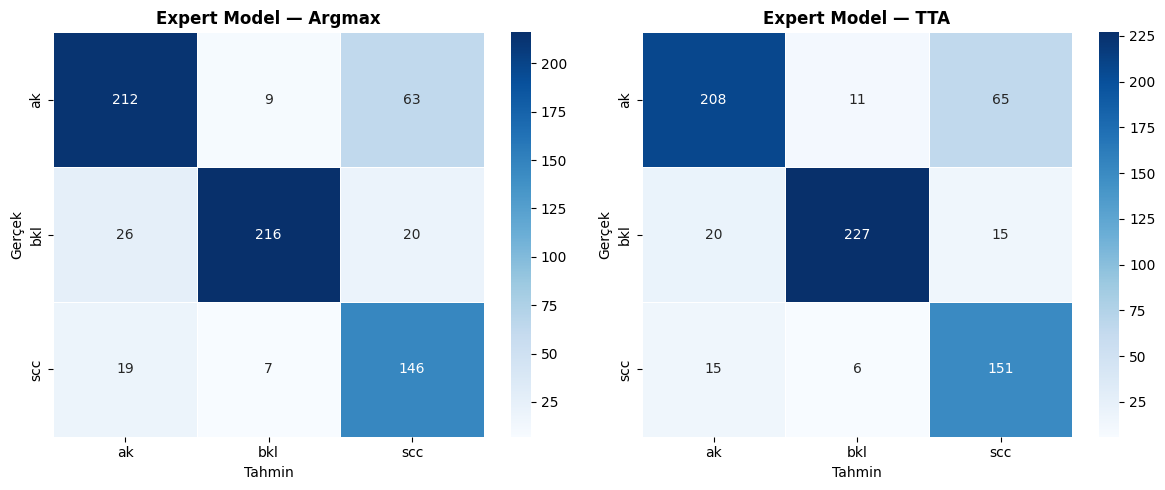

In [16]:
# ── Confusion Matrix ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (preds, lbl, title) in zip(axes, [
    (tp, tl, 'Argmax'),
    (tta_p, tta_l, 'TTA'),
]):
    cm = confusion_matrix(lbl, preds, labels=[0,1,2])
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES, cmap='Blues', linewidths=.4, ax=ax)
    ax.set_title(f'Expert Model — {title}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Gerçek'); ax.set_xlabel('Tahmin')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/cm_expert.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ── Final Model Kaydet ──────────────────────────────────────
final_path = f'{SAVE_DIR}/skinxai_expert_final.pth'
torch.save({
    'model_state_dict':     model.state_dict(),
    'class_names':          CLASS_NAMES,   # ['ak', 'bkl', 'scc']
    'val_f1':               ckpt['val_f1'],
    'test_f1_tta':          float(tta_f1),
    'per_class_recall_tta': tta_pc.tolist(),
    'num_classes':          3,
}, final_path)

print(f'✅ Expert model kaydedildi: {final_path}')
print()
print('predict.py CASCADE için:')
print('  --expert skinxai_expert_final.pth')
print()
print(f'TTA F1   : {tta_f1:.4f}')
print(f'TTA Acc  : {tta_acc*100:.1f}%')
for i, cls in enumerate(CLASS_NAMES):
    print(f'  {cls:6s}: {tta_pc[i]*100:.1f}%')
print()
print('📥 Output sekmesinden skinxai_expert_final.pth indir.')

✅ Expert model kaydedildi: /kaggle/working/models_expert/skinxai_expert_final.pth

predict.py CASCADE için:
  --expert skinxai_expert_final.pth

TTA F1   : 0.8120
TTA Acc  : 81.6%
  ak    : 73.2%
  bkl   : 86.6%
  scc   : 87.8%

📥 Output sekmesinden skinxai_expert_final.pth indir.
